Summary Statistics:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0.000000   
25%         0

c:\Users\Simbo\Desktop\solar-challenge-week1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


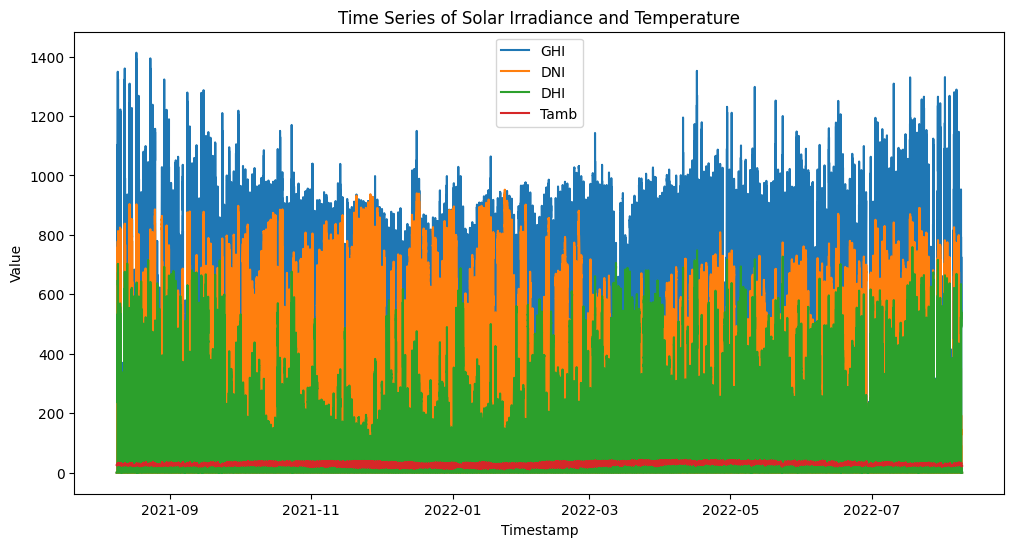

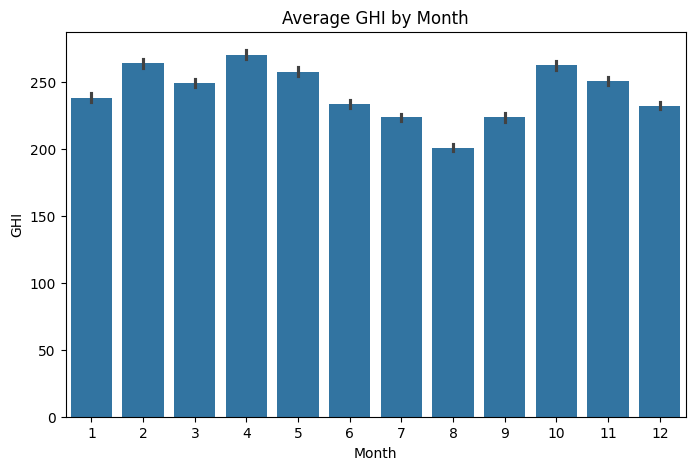

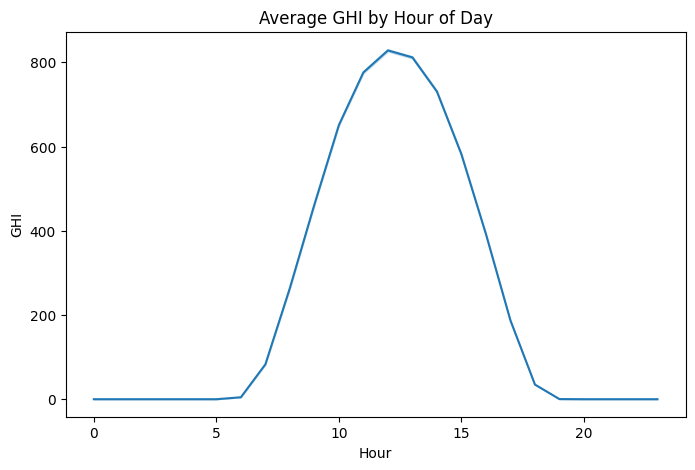

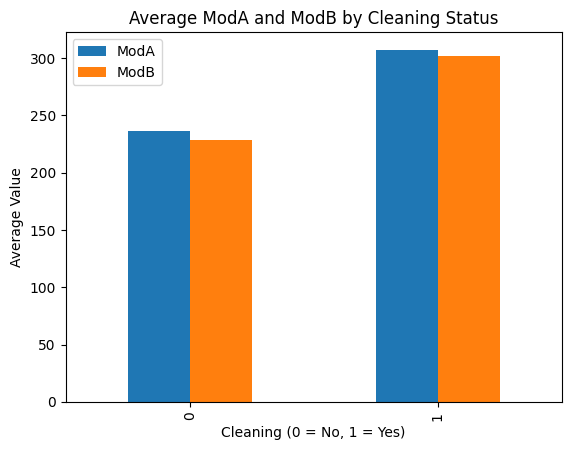

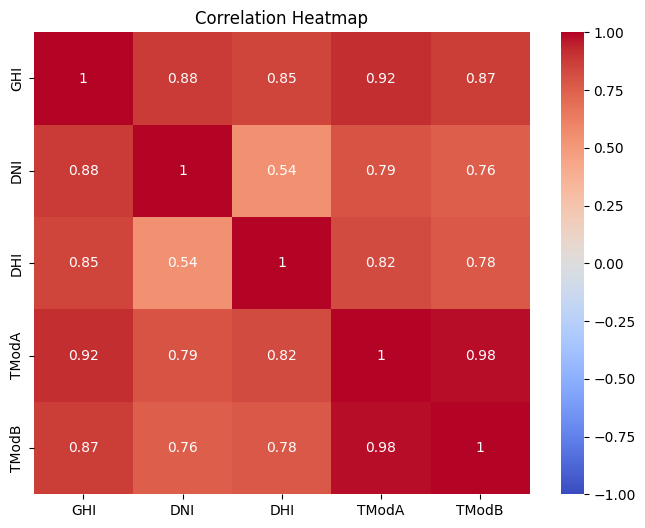

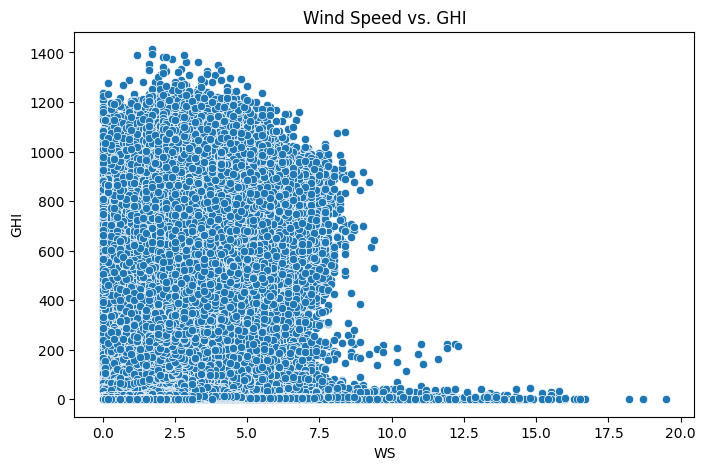

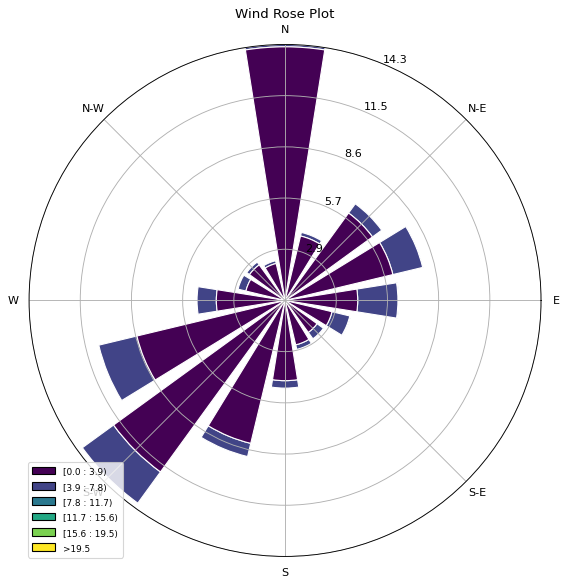

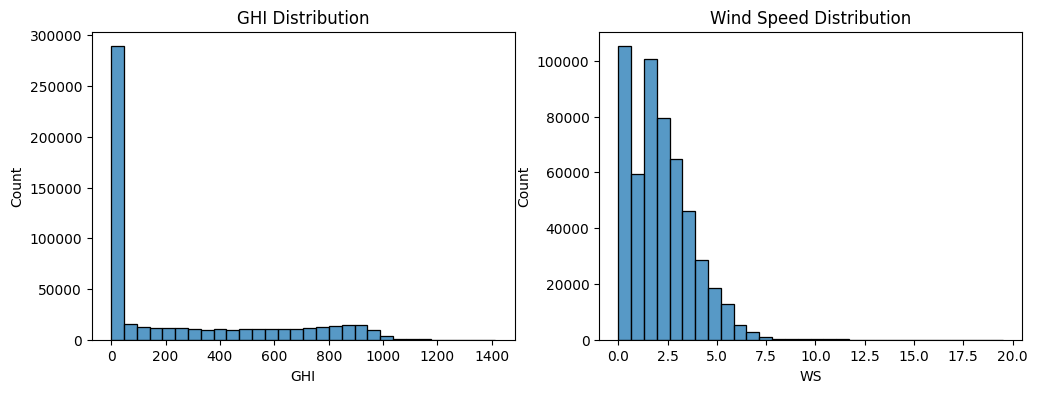

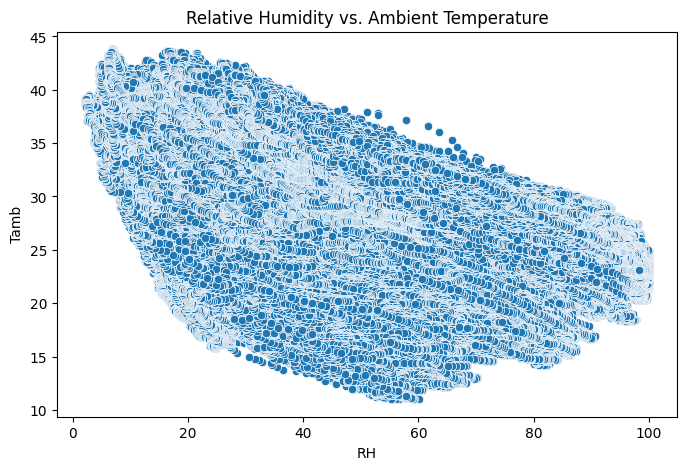

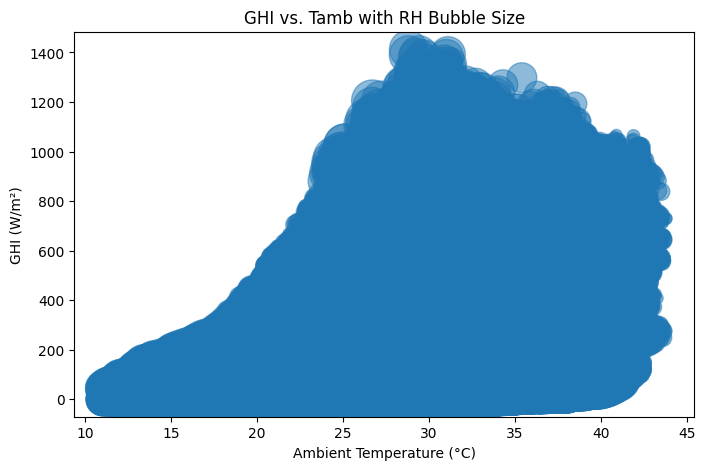

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from windrose import WindroseAxes
%matplotlib inline

# 1. Data Loading and Profiling
try:
    df = pd.read_csv('../data/benin.csv', sep=',', low_memory=False)
    
    # Convert all 'null' strings to actual NaN values
    df = df.replace('null', np.nan)
    
    # Summary statistics
    print("Summary Statistics:")
    print(df.describe())
    
    # Missing values
    missing_values = df.isna().sum()
    missing_percentage = (df.isna().sum() / len(df)) * 100
    missing_report = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    print("\nMissing Values Report (columns with >5% nulls):")
    print(missing_report[missing_report['Percentage'] > 5])

except FileNotFoundError:
    print("Error: File 'data/togo.csv' not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {str(e)}")

# 2. Outlier Detection and Cleaning
if 'df' in locals():
    try:
        # Compute Z-scores for outlier detection
        key_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
        
        # Only use columns that exist in the dataframe
        available_columns = [col for col in key_columns if col in df.columns]
        
        if available_columns:
            z_scores = df[available_columns].apply(zscore, nan_policy='omit')
            outliers = (z_scores.abs() > 3).any(axis=1)
            print(f"\nNumber of rows with outliers: {outliers.sum()}")
            if outliers.any():
                print("Outlier samples:")
                print(df[outliers][available_columns].head())
            
            # Impute missing values with median
            for col in available_columns:
                df[col] = df[col].fillna(df[col].median())
            
            # Drop Comments column if it exists
            df = df.drop(columns=['Comments'], errors='ignore')
            
            # Clip negative values to 0
            df[available_columns] = df[available_columns].clip(lower=0)
            
            # Export cleaned data
            df.to_csv('data/benin_clean.csv', index=False)
            print("\nCleaned data exported to data/benin_clean.csv")
        else:
            print("None of the key columns found in the dataframe")

    except Exception as e:
        print(f"Error during cleaning: {str(e)}")

# 3. Time Series Analysis
if 'df' in locals() and 'Timestamp' in df.columns:
    try:
        # Convert Timestamp to datetime
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        
        # Line plot for available metrics
        plt.figure(figsize=(12, 6))
        
        metrics_to_plot = []
        for metric in ['GHI', 'DNI', 'DHI', 'Tamb']:
            if metric in df.columns:
                plt.plot(df['Timestamp'], df[metric], label=metric)
                metrics_to_plot.append(metric)
        
        if metrics_to_plot:
            plt.xlabel('Timestamp')
            plt.ylabel('Value')
            plt.title('Time Series of Solar Irradiance and Temperature')
            plt.legend()
            plt.show()
        
            # Monthly and hourly patterns
            df['Month'] = df['Timestamp'].dt.month
            df['Hour'] = df['Timestamp'].dt.hour
            
            # Average GHI by month if GHI exists
            if 'GHI' in df.columns:
                plt.figure(figsize=(8, 5))
                sns.barplot(x='Month', y='GHI', data=df)
                plt.title('Average GHI by Month')
                plt.show()
                
                # Average GHI by hour
                plt.figure(figsize=(8, 5))
                sns.lineplot(x='Hour', y='GHI', data=df)
                plt.title('Average GHI by Hour of Day')
                plt.show()
        else:
            print("No suitable metrics found for time series plotting")

    except Exception as e:
        print(f"Error during time series analysis: {str(e)}")

# 4. Cleaning Impact Analysis
if 'df' in locals() and 'Cleaning' in df.columns:
    try:
        # Group by Cleaning flag
        cleaning_cols = [col for col in ['ModA', 'ModB'] if col in df.columns]
        
        if cleaning_cols:
            cleaning_impact = df.groupby('Cleaning')[cleaning_cols].mean().reset_index()
            
            # Bar plot
            cleaning_impact.plot(kind='bar', x='Cleaning', y=cleaning_cols, 
                               title='Average ModA and ModB by Cleaning Status')
            plt.xlabel('Cleaning (0 = No, 1 = Yes)')
            plt.ylabel('Average Value')
            plt.show()
        else:
            print("No ModA or ModB columns found for cleaning impact analysis")

    except Exception as e:
        print(f"Error during cleaning impact analysis: {str(e)}")

# 5. Correlation and Relationship Analysis
if 'df' in locals():
    try:
        # Correlation heatmap
        corr_cols = [col for col in ['GHI', 'DNI', 'DHI', 'TModA', 'TModB'] if col in df.columns]
        
        if len(corr_cols) > 1:
            corr = df[corr_cols].corr()
            plt.figure(figsize=(8, 6))
            sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
            plt.title('Correlation Heatmap')
            plt.show()
        
        # Scatter plot if both WS and GHI exist
        if 'WS' in df.columns and 'GHI' in df.columns:
            plt.figure(figsize=(8, 5))
            sns.scatterplot(x='WS', y='GHI', data=df)
            plt.title('Wind Speed vs. GHI')
            plt.show()

    except Exception as e:
        print(f"Error during correlation analysis: {str(e)}")

# 6. Wind and Distribution Analysis
if 'df' in locals():
    try:
        # Wind rose plot if WD and WS exist
        if 'WD' in df.columns and 'WS' in df.columns:
            ax = WindroseAxes.from_ax()
            ax.bar(df['WD'], df['WS'], normed=True, opening=0.8, edgecolor='white')
            ax.set_legend()
            plt.title('Wind Rose Plot')
            plt.show()
        
        # Histograms
        plt.figure(figsize=(12, 4))
        
        # GHI histogram if exists
        if 'GHI' in df.columns:
            plt.subplot(1, 2, 1)
            sns.histplot(df['GHI'], bins=30)
            plt.title('GHI Distribution')
        
        # WS histogram if exists
        if 'WS' in df.columns:
            plt.subplot(1, 2, 2)
            sns.histplot(df['WS'], bins=30)
            plt.title('Wind Speed Distribution')
        
        plt.show()

    except Exception as e:
        print(f"Error during wind analysis: {str(e)}")

# 7. Temperature Analysis
if 'df' in locals():
    try:
        # RH vs. Tamb scatter plot if both exist
        if 'RH' in df.columns and 'Tamb' in df.columns:
            plt.figure(figsize=(8, 5))
            sns.scatterplot(x='RH', y='Tamb', data=df)
            plt.title('Relative Humidity vs. Ambient Temperature')
            plt.show()
        
        # Bubble chart if all three exist
        if all(col in df.columns for col in ['Tamb', 'GHI', 'RH']):
            plt.figure(figsize=(8, 5))
            plt.scatter(df['Tamb'], df['GHI'], s=df['RH']*10, alpha=0.5)
            plt.xlabel('Ambient Temperature (°C)')
            plt.ylabel('GHI (W/m²)')
            plt.title('GHI vs. Tamb with RH Bubble Size')
            plt.show()

    except Exception as e:
        print(f"Error during temperature analysis: {str(e)}")